# 🤖 Impacto del uso de la IA en estudiantes
**Dataset:** `Data_set_02.csv` — 8.000 estudiantes, 26 variables

---
## 0. Configuración del entorno virtual

Ejecuta esto en tu **terminal** antes de abrir Jupyter:

```bash
# Crear y activar entorno virtual
python -m venv venv_ia_impacto

# Windows:
venv_ia_impacto\Scripts\activate

# Mac/Linux:
source venv_ia_impacto/bin/activate

# Instalar dependencias
pip install pandas numpy matplotlib seaborn scikit-learn jupyter ipykernel

# Registrar como kernel de Jupyter
python -m ipykernel install --user --name=venv_ia_impacto --display-name "Python (IA Impacto)"

# Lanzar Jupyter
jupyter notebook
```
> ⚠️ Al abrir el notebook: **Kernel → Change Kernel → Python (IA Impacto)**
>
> ⚠️ Coloca `Data_set_02.csv` en la **misma carpeta** que este notebook.

---
## 1. Importar librerías y cargar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('./Data/Data_set_02.csv')
print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 8000 filas × 26 columnas


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


---
## 2. Resumen general del dataset

In [3]:
# Tabla de estadísticas descriptivas (solo columnas numéricas clave)
cols_key = [
    'age', 'study_hours_per_day', 'ai_usage_time_minutes',
    'ai_dependency_score', 'ai_generated_content_percentage',
    'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
    'final_score', 'sleep_hours', 'social_media_hours'
]
df[cols_key].describe().round(2)

,age,study_hours_per_day,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,final_score,sleep_hours,social_media_hours
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,18.97,3.29,88.99,5.52,50.06,59.36,5.47,59.50,56.81,6.47,3.01
std,3.15,1.58,52.18,2.88,29.44,34.87,2.87,23.16,13.46,1.44,1.74
min,14.00,0.50,0.00,1.00,0.00,0.00,1.00,20.00,12.70,4.00,0.00
25%,16.00,1.90,43.00,3.00,25.00,29.00,3.00,39.75,47.30,5.20,1.50
50%,19.00,3.30,89.00,6.00,50.00,59.00,6.00,59.00,56.90,6.40,3.00
75%,22.00,4.60,134.00,8.00,76.00,90.00,8.00,80.00,66.20,7.70,4.50
max,24.00,6.00,179.00,10.00,100.00,119.00,10.00,99.00,95.80,9.00,6.00


In [4]:
# Valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print('Columnas con valores nulos:')
print(nulls.to_string())
print('\nNota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.')
print('Corresponden a estudiantes que no usan IA (uses_ai = 0).')

Columnas con valores nulos:
ai_tools_used       1362
ai_usage_purpose    1346

Nota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.
Corresponden a estudiantes que no usan IA (uses_ai = 0).


---
## 3. Perfil del estudiante — variables categóricas

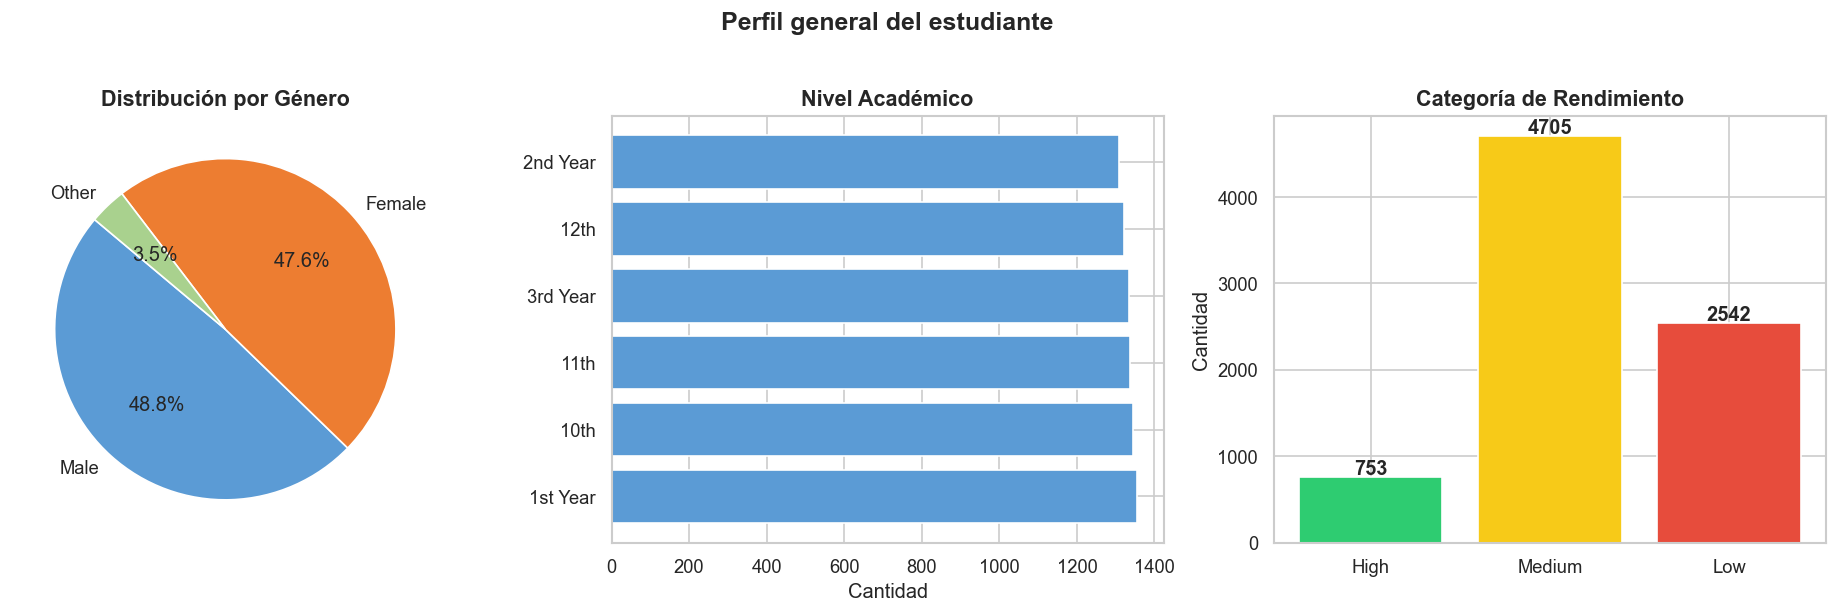

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Género
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#5b9bd5','#ed7d31','#a9d18e'], startangle=140)
axes[0].set_title('Distribución por Género')

# Nivel académico
grade_counts = df['grade_level'].value_counts()
axes[1].barh(grade_counts.index, grade_counts.values,
             color='#5b9bd5', edgecolor='white')
axes[1].set_title('Nivel Académico')
axes[1].set_xlabel('Cantidad')

# Rendimiento
perf_counts = df['performance_category'].value_counts().reindex(['High','Medium','Low'])
axes[2].bar(perf_counts.index, perf_counts.values,
            color=['#2ecc71','#f7ca18','#e74c3c'], edgecolor='white')
axes[2].set_title('Categoría de Rendimiento')
axes[2].set_ylabel('Cantidad')
for i, v in enumerate(perf_counts.values):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Perfil general del estudiante', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Uso de la IA — ¿Quién la usa y cómo?

In [6]:
# % que usa IA
usa_ia = df['uses_ai'].value_counts(normalize=True) * 100
print(f"Usan IA: {usa_ia.get(1, 0):.1f}%")
print(f"No usan IA: {usa_ia.get(0, 0):.1f}%")

Usan IA: 64.1%
No usan IA: 35.9%


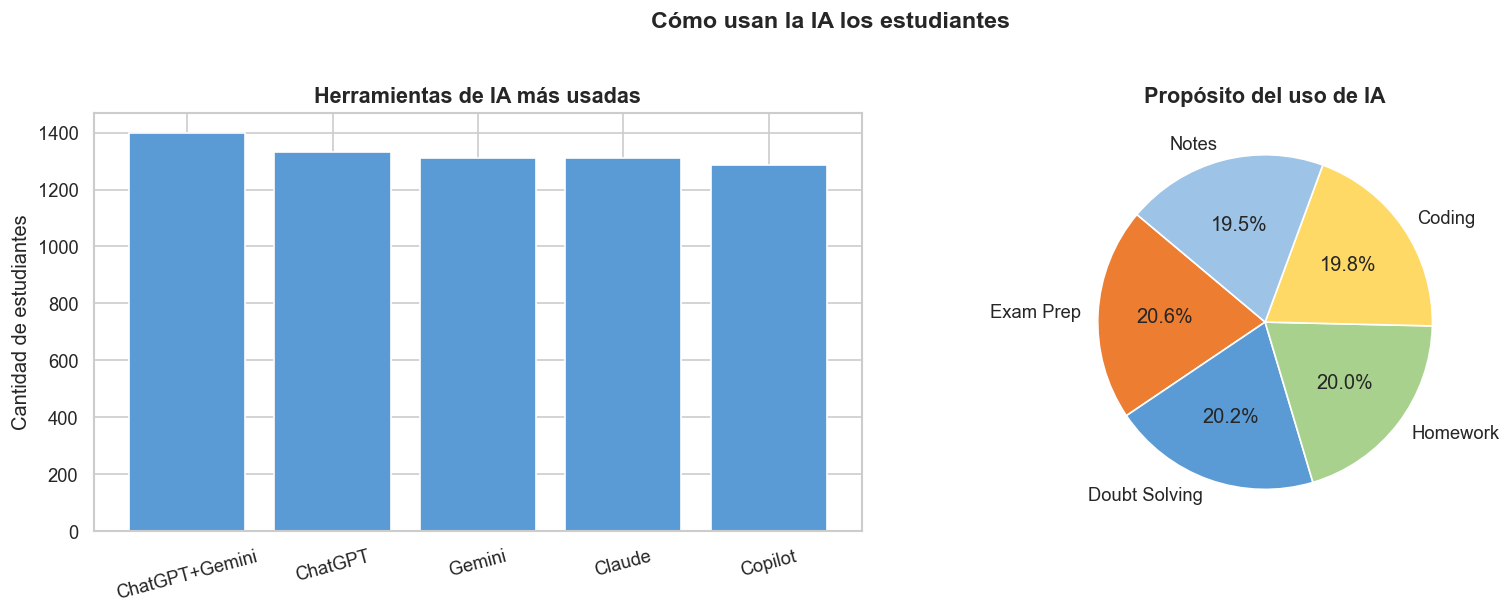

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Herramientas más usadas
tools = df['ai_tools_used'].value_counts().dropna()
axes[0].bar(tools.index, tools.values, color='#5b9bd5', edgecolor='white')
axes[0].set_title('Herramientas de IA más usadas')
axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].tick_params(axis='x', rotation=15)

# Propósito de uso
purpose = df['ai_usage_purpose'].value_counts().dropna()
colors_p = ['#ed7d31','#5b9bd5','#a9d18e','#ffd966','#9dc3e6']
axes[1].pie(purpose, labels=purpose.index, autopct='%1.1f%%',
            colors=colors_p, startangle=140)
axes[1].set_title('Propósito del uso de IA')

plt.suptitle('Cómo usan la IA los estudiantes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

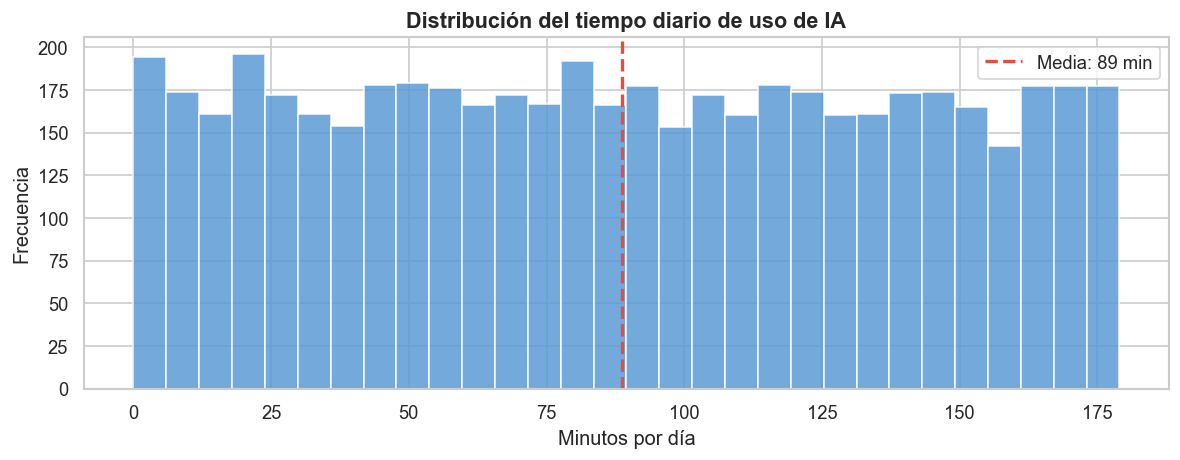

In [13]:
# Distribución del tiempo de uso de IA (minutos por día)
ai_users = df[df['uses_ai'] == 1]

plt.figure(figsize=(10, 4))
plt.hist(ai_users['ai_usage_time_minutes'], bins=30,
         color='#5b9bd5', edgecolor='white', alpha=0.85)
plt.axvline(ai_users['ai_usage_time_minutes'].mean(), color='#e74c3c',
            linestyle='--', linewidth=2,
            label=f"Media: {ai_users['ai_usage_time_minutes'].mean():.0f} min")
plt.title('Distribución del tiempo diario de uso de IA')
plt.xlabel('Minutos por día')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Impacto de la IA en el rendimiento académico

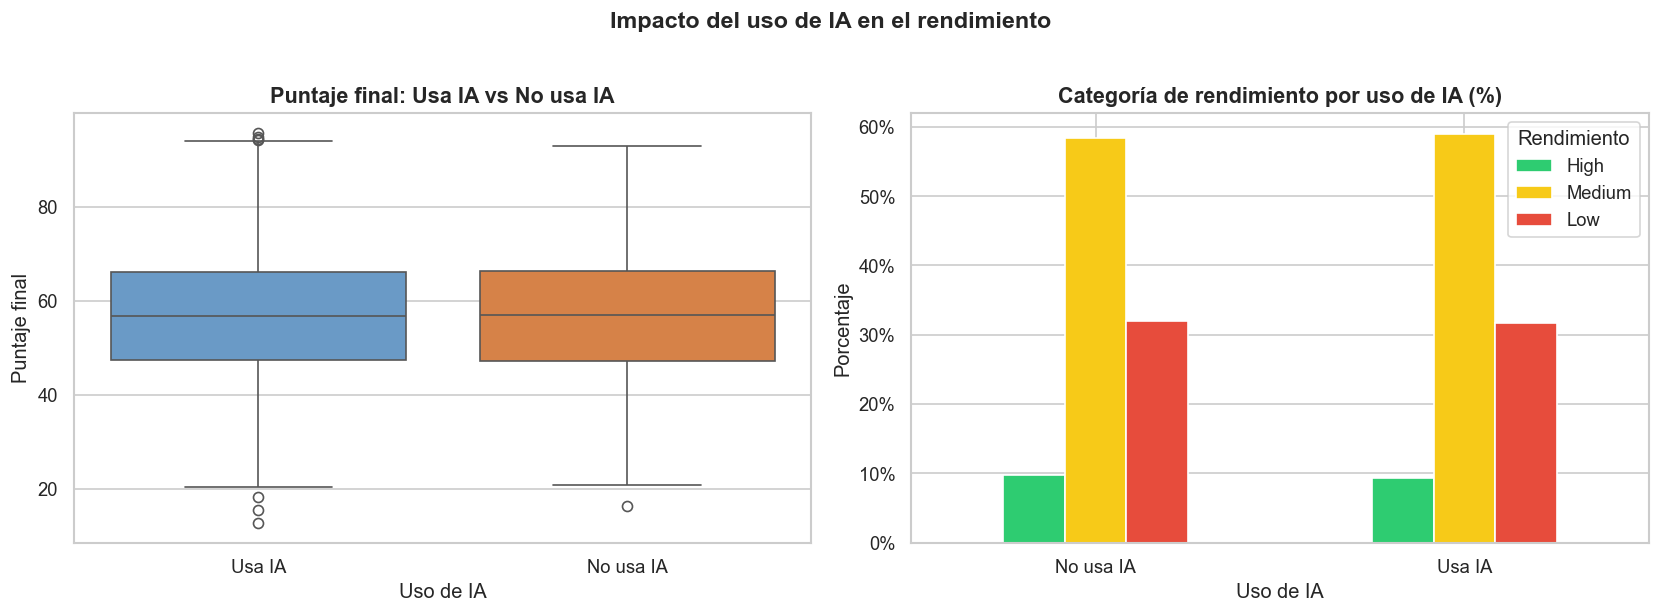

In [14]:
# Comparación de puntaje final: usuarios IA vs no usuarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['Uso de IA'] = df['uses_ai'].map({1: 'Usa IA', 0: 'No usa IA'})
sns.boxplot(data=df, x='Uso de IA', y='final_score',
            palette={'Usa IA': '#5b9bd5', 'No usa IA': '#ed7d31'},
            ax=axes[0])
axes[0].set_title('Puntaje final: Usa IA vs No usa IA')
axes[0].set_ylabel('Puntaje final')

# Rendimiento por categoría de uso de IA
perf_ia = df.groupby(['Uso de IA', 'performance_category']).size().unstack(fill_value=0)
perf_ia_pct = perf_ia.div(perf_ia.sum(axis=1), axis=0) * 100
perf_ia_pct[['High','Medium','Low']].plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#f7ca18','#e74c3c'],
    edgecolor='white')
axes[1].set_title('Categoría de rendimiento por uso de IA (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Rendimiento')

plt.suptitle('Impacto del uso de IA en el rendimiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

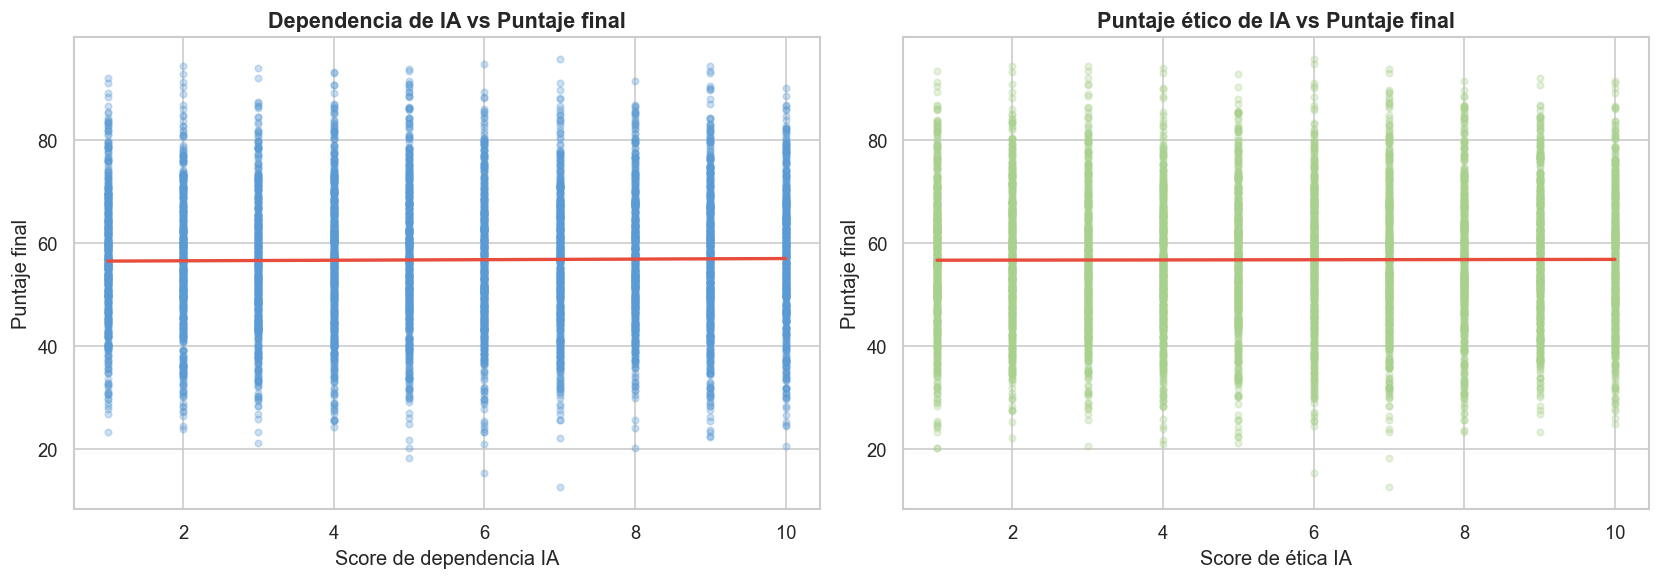

In [15]:
# Correlación: dependencia de IA vs puntaje final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_users = df[df['uses_ai'] == 1]

# Dependencia vs puntaje
axes[0].scatter(ai_users['ai_dependency_score'], ai_users['final_score'],
                alpha=0.3, color='#5b9bd5', s=15)
m, b = np.polyfit(ai_users['ai_dependency_score'], ai_users['final_score'], 1)
x_line = np.linspace(ai_users['ai_dependency_score'].min(), ai_users['ai_dependency_score'].max())
axes[0].plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2)
axes[0].set_title('Dependencia de IA vs Puntaje final')
axes[0].set_xlabel('Score de dependencia IA')
axes[0].set_ylabel('Puntaje final')

# Ética de IA vs puntaje
axes[1].scatter(ai_users['ai_ethics_score'], ai_users['final_score'],
                alpha=0.3, color='#a9d18e', s=15)
m2, b2 = np.polyfit(ai_users['ai_ethics_score'], ai_users['final_score'], 1)
x_line2 = np.linspace(ai_users['ai_ethics_score'].min(), ai_users['ai_ethics_score'].max())
axes[1].plot(x_line2, m2*x_line2 + b2, color='#e74c3c', linewidth=2)
axes[1].set_title('Puntaje ético de IA vs Puntaje final')
axes[1].set_xlabel('Score de ética IA')
axes[1].set_ylabel('Puntaje final')

plt.tight_layout()
plt.show()

---
## 6. Hábitos del estudiante — Sueño, estudio y redes sociales

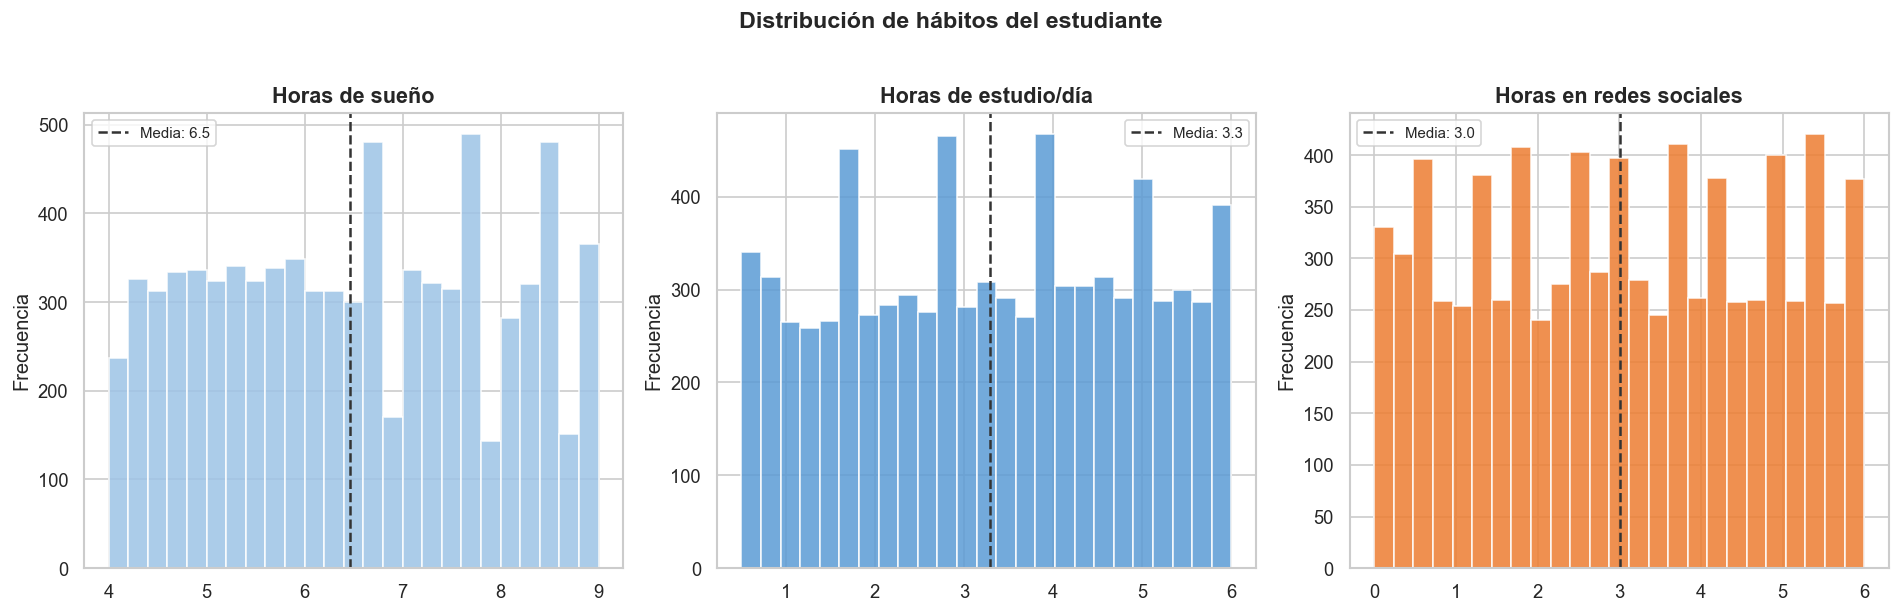

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
habit_cols = ['sleep_hours', 'study_hours_per_day', 'social_media_hours']
habit_labels = ['Horas de sueño', 'Horas de estudio/día', 'Horas en redes sociales']
habit_colors = ['#9dc3e6', '#5b9bd5', '#ed7d31']

for ax, col, label, color in zip(axes, habit_cols, habit_labels, habit_colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():.1f}')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de hábitos del estudiante', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

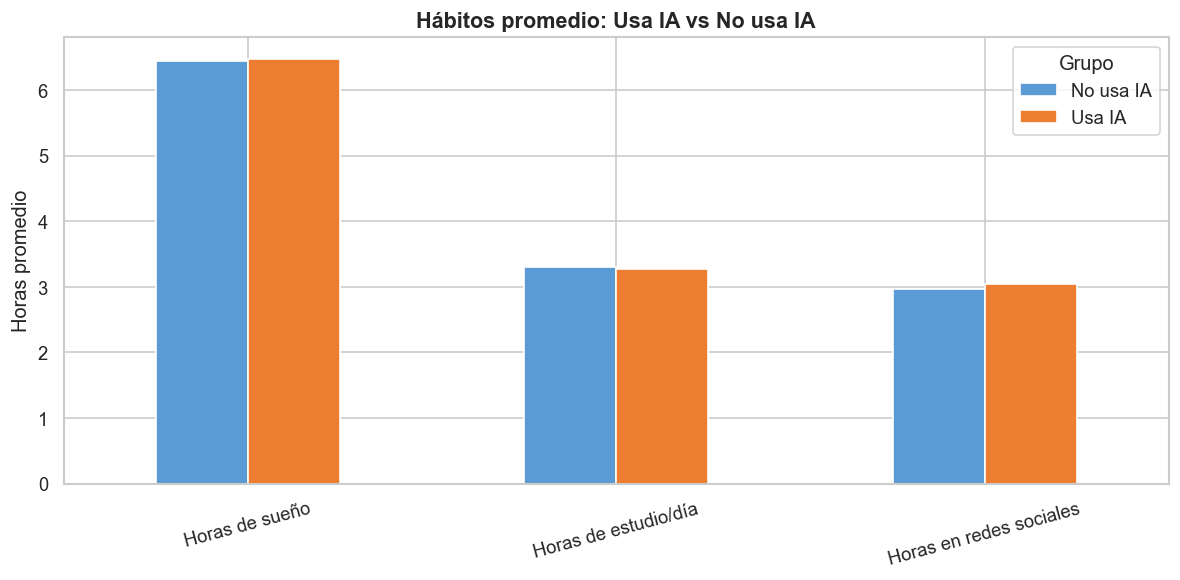

In [16]:
# Comparación de hábitos: usa IA vs no usa IA
habit_compare = df.groupby('Uso de IA')[habit_cols].mean().T
habit_compare.index = habit_labels
habit_compare.plot(kind='bar', figsize=(10, 5),
                   color=['#5b9bd5','#ed7d31'], edgecolor='white')
plt.title('Hábitos promedio: Usa IA vs No usa IA', fontweight='bold')
plt.ylabel('Horas promedio')
plt.xticks(rotation=15)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

---
## 7. Mapa de correlaciones

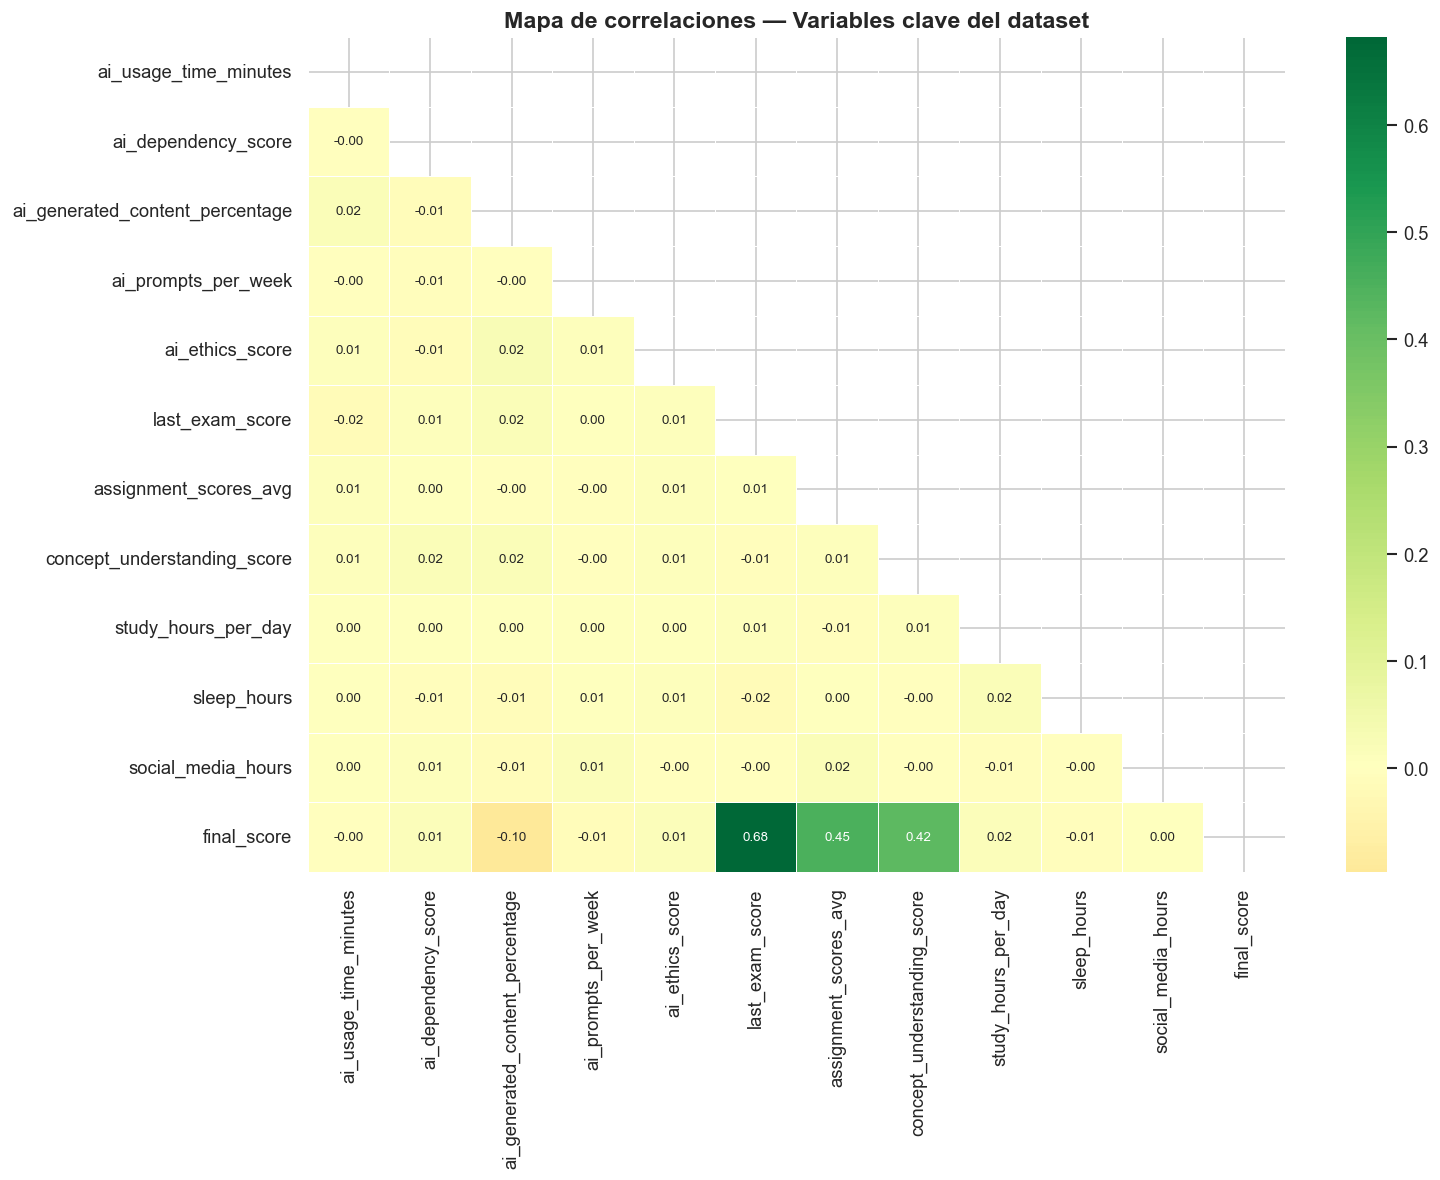

In [17]:
corr_cols = [
    'ai_usage_time_minutes', 'ai_dependency_score',
    'ai_generated_content_percentage', 'ai_prompts_per_week',
    'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg',
    'concept_understanding_score', 'study_hours_per_day',
    'sleep_hours', 'social_media_hours', 'final_score'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Mapa de correlaciones — Variables clave del dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Tabla resumen por rendimiento académico

In [18]:
summary = df.groupby('performance_category').agg(
    n_estudiantes=('student_id', 'count'),
    pct_usa_ia=('uses_ai', lambda x: f"{x.mean()*100:.1f}%"),
    tiempo_ia_min=('ai_usage_time_minutes', 'mean'),
    dependencia_ia=('ai_dependency_score', 'mean'),
    etica_ia=('ai_ethics_score', 'mean'),
    horas_estudio=('study_hours_per_day', 'mean'),
    horas_sueno=('sleep_hours', 'mean'),
    redes_sociales=('social_media_hours', 'mean'),
    puntaje_final=('final_score', 'mean')
).round(2).reindex(['High','Medium','Low'])

print('=== Resumen por categoría de rendimiento ===')
summary

=== Resumen por categoría de rendimiento ===


,n_estudiantes,pct_usa_ia,tiempo_ia_min,dependencia_ia,etica_ia,horas_estudio,horas_sueno,redes_sociales,puntaje_final
performance_category,,,,,,,,,
High,753,63.1%,88.60,5.69,5.56,3.38,6.39,3.03,80.70
Medium,4705,64.4%,89.05,5.48,5.50,3.29,6.47,3.01,61.24
Low,2542,63.9%,88.99,5.52,5.39,3.26,6.47,3.01,41.54


---
## 9. Dataset 3 - Percepcion de reemplazo por IA y nivel de agotamiento

Los siguientes 4 graficos de dispersion analizan la relacion entre la percepcion de reemplazo por IA y el nivel de agotamiento, uno por celda.
Se utiliza el dataset original Data_set_03.csv, con las variables ai_replaces_my_tasks_pct y burnout_score (presentada como nivel de agotamiento).

Cada grafico incluye media, mediana, desviacion estandar y correlacion para facilitar la interpretacion estadistica.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset usado
df_ds3 = pd.read_csv('./Data/Data_set_03.csv')

# Se usan las 4 profesiones mas repetidas del dataset
profesiones = df_ds3['job_role'].value_counts().head(4).index.tolist()

def graficar_profesion(df, profesion):
    df_prof = df[df['job_role'] == profesion]

    x = df_prof['ai_replaces_my_tasks_pct']
    y = df_prof['burnout_score']

    y_mean = y.mean()
    y_std = y.std(ddof=1)
    y_median = y.median()
    corr = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=34, color='#2f5597', alpha=0.35, edgecolors='none', label='Observaciones')
    plt.plot(x_line, y_line, color='#c23b22', linewidth=2.2, label='Tendencia lineal')

    plt.axhline(y_mean, color='#a61c00', linewidth=2.2, label=f'Media = {y_mean:.2f}')
    plt.axhline(y_median, color='#38761d', linestyle='--', linewidth=2.2, label=f'Mediana = {y_median:.2f}')
    plt.axhline(y_mean - y_std, color='#ed7d31', linestyle=':', linewidth=2)
    plt.axhline(y_mean + y_std, color='#ed7d31', linestyle=':', linewidth=2, label=f'Desv. est. = {y_std:.2f}')

    plt.text(
        0.02, 0.98,
        f'n = {len(df_prof)}\nMedia = {y_mean:.2f}\nMediana = {y_median:.2f}\nDesv. est. = {y_std:.2f}\nCorrelacion r = {corr:.3f}',
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#b7b7b7')
    )

    plt.title(f'Percepcion de reemplazo por IA vs nivel de agotamiento\n{profesion}')
    plt.xlabel('Percepcion de reemplazo por IA (%)')
    plt.ylabel('Nivel de agotamiento')
    plt.grid(True, alpha=0.25)
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

print('Profesiones seleccionadas:')
for i, profesion in enumerate(profesiones, start=1):
    print(f'{i}. {profesion}')

Profesiones seleccionadas:
1. Software Engineer
2. AI Researcher
3. Data Scientist
4. AI Ethics Officer


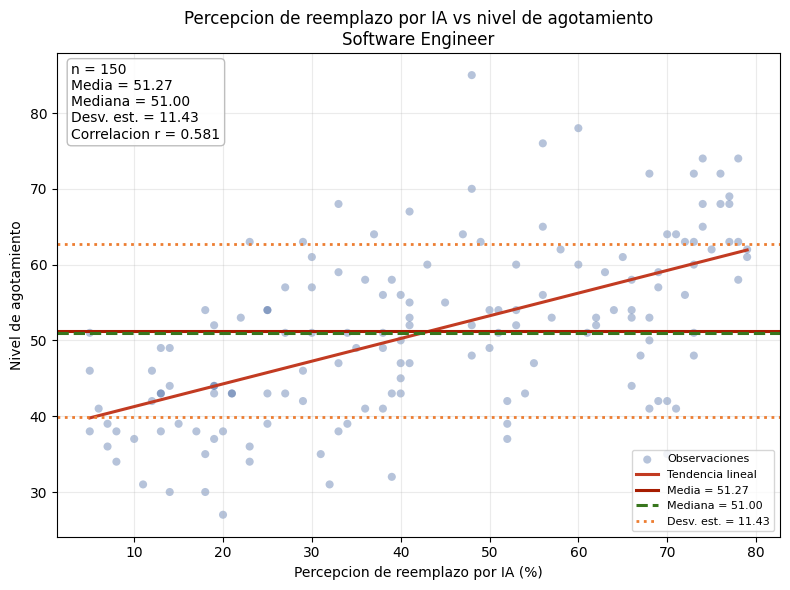

In [7]:
# Grafico 1
graficar_profesion(df_ds3, profesiones[0])

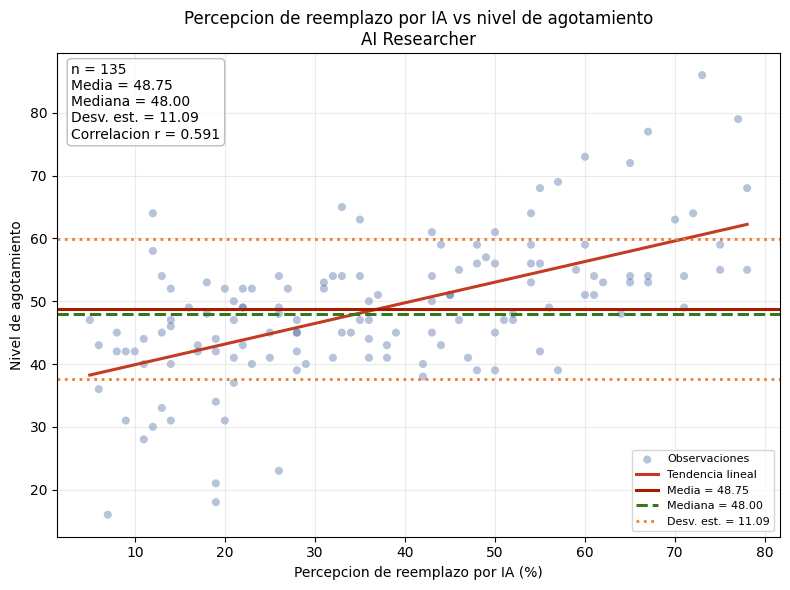

In [8]:
# Grafico 2
graficar_profesion(df_ds3, profesiones[1])

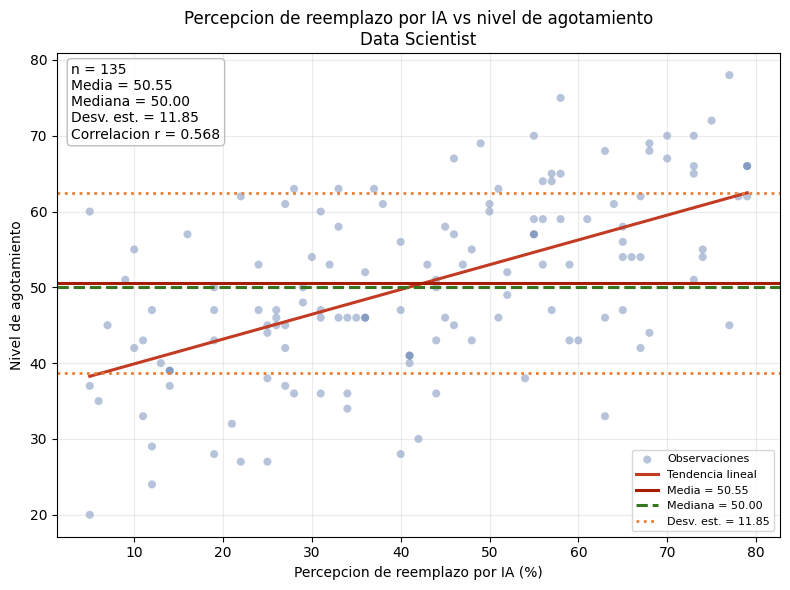

In [9]:
# Grafico 3
graficar_profesion(df_ds3, profesiones[2])

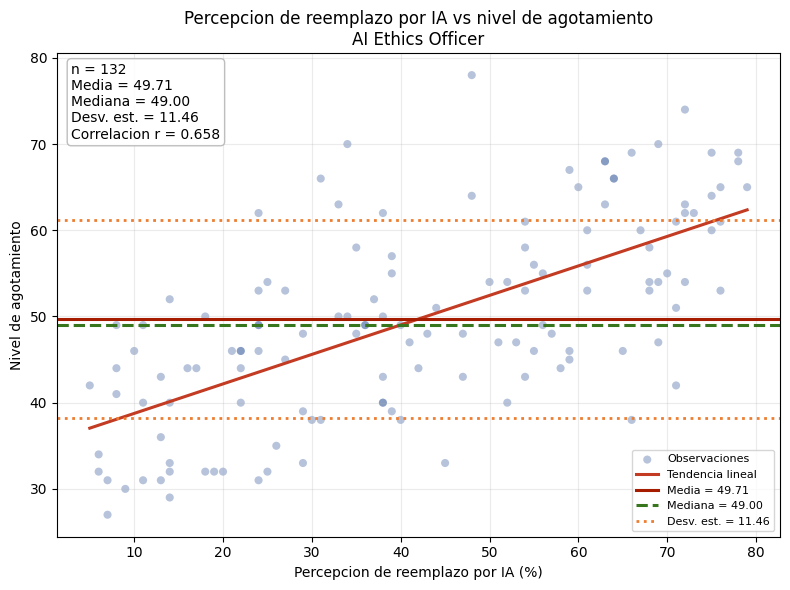

In [10]:
# Grafico 4
graficar_profesion(df_ds3, profesiones[3])

### Casilla de interpretacion simple

En los 4 graficos se observa una tendencia positiva: cuando sube la percepcion de reemplazo por IA, tambien sube el nivel de agotamiento.

Interpretacion rapida por profesion:
- Software Engineer: es el grupo con mayor agotamiento promedio (media = 51.27).
- AI Researcher: muestra el menor agotamiento promedio (media = 48.75).
- Data Scientist: tiene un nivel intermedio de agotamiento (media = 50.55) y la correlacion mas baja (r = 0.568).
- AI Ethics Officer: es donde mas fuerte se relaciona el miedo al reemplazo con el agotamiento (correlacion r = 0.658).


- Si miramos quien se siente peor en promedio, es Software Engineer.
- Si miramos quien se siente menos afectado en promedio, es AI Researcher.
- Si miramos a quien le afecta mas la idea de reemplazo de IA, es AI Ethics Officer.


---
## 10. OECD Data Explorer API (JSON) - IA por pais

> Objetivo: descargar datos de la API de OECD en formato JSON, convertirlos a tabla util y guardar un JSON limpio para analisis en el proyecto.

JSON crudo guardado en: Data\oecd_ai_patents_2020_raw.json
JSON limpio guardado en: Data\oecd_ai_patents_2020_clean.json
Paises con valor > 0: 55


,iso3,country,year,ai_patents_value
0,USA,United States,2020,3623.222656
1,CHN,China (People’s Republic of),2020,2644.944824
2,JPN,Japan,2020,1945.824951
3,KOR,Korea,2020,1573.166748
4,DEU,Germany,2020,723.083313
5,TWN,Chinese Taipei,2020,353.333313
6,CAN,Canada,2020,245.879807
7,FRA,France,2020,209.924194
8,GBR,United Kingdom,2020,191.833298
9,CHE,Switzerland,2020,126.404800


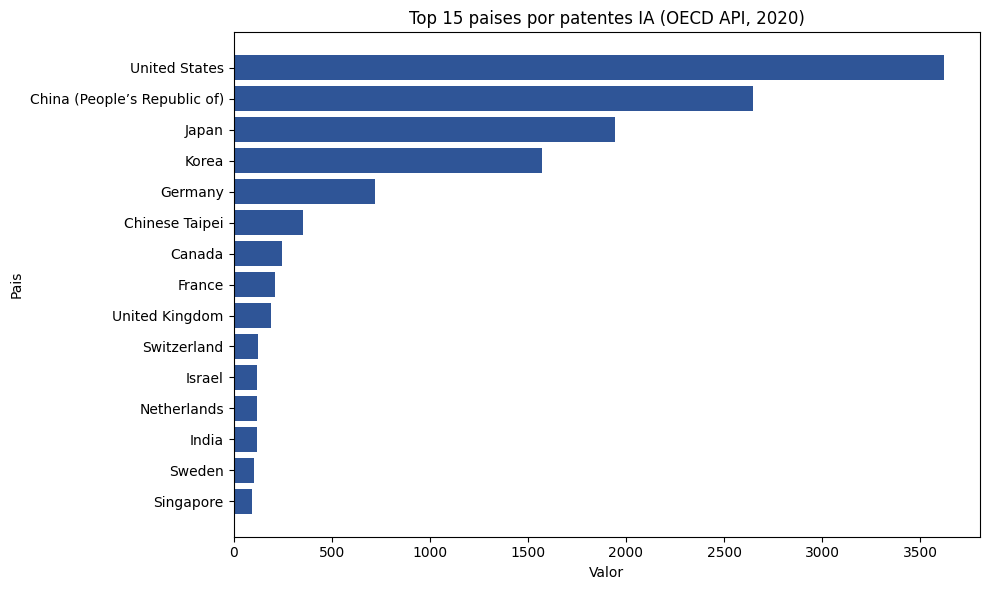

In [5]:
import json
import urllib.request
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# API JSON desde OECD Data Explorer (IA por pais, 2020, familias de patentes IP5)
api_url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.STI.PIE,DSD_PATENTS%40DF_PATENTS_OECDSPECIFIC/"
    "9P50_3.A.PF.PATN_FM.PRIORITY.._Z.APPLICANT._Z._Z.AI"
    "?startPeriod=2020&dimensionAtObservation=AllDimensions&format=jsondata"
)

# Algunas instancias de la API rechazan requests sin User-Agent
request = urllib.request.Request(
    api_url,
    headers={
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/json",
    },
)

with urllib.request.urlopen(request) as response:
    payload = json.loads(response.read().decode("utf-8"))

# Guardar JSON crudo para trazabilidad
raw_json_path = Path("./Data/oecd_ai_patents_2020_raw.json")
raw_json_path.write_text(
    json.dumps(payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

# Parseo SDMX-JSON -> tabla plana
if "structure" in payload.get("data", {}):
    obs_dims = payload["data"]["structure"]["dimensions"]["observation"]
else:
    obs_dims = payload["data"]["structures"][0]["dimensions"]["observation"]

dim_ids = [d["id"] for d in obs_dims]
dim_values = [d["values"] for d in obs_dims]

records = []
for obs_key, obs_val in payload["data"]["dataSets"][0]["observations"].items():
    idx = [int(i) for i in obs_key.split(":")]
    rec = {}
    for i, dim_id in enumerate(dim_ids):
        selected = dim_values[i][idx[i]]
        rec[dim_id] = selected.get("id")
        rec[f"{dim_id}_label"] = selected.get("name")

    rec["OBS_VALUE"] = obs_val[0] if len(obs_val) > 0 else None
    records.append(rec)

df_oecd = pd.DataFrame(records)
df_oecd["OBS_VALUE"] = pd.to_numeric(df_oecd["OBS_VALUE"], errors="coerce")

# Limpieza para analisis georreferenciado:
# - solo paises ISO3
# - quitar valores nulos o cero
df_oecd_clean = (
    df_oecd.loc[
        df_oecd["REF_AREA"].str.fullmatch(r"[A-Z]{3}", na=False)
        & df_oecd["OBS_VALUE"].notna()
        & (df_oecd["OBS_VALUE"] > 0),
        ["REF_AREA", "REF_AREA_label", "TIME_PERIOD", "OBS_VALUE"],
    ]
    .rename(
        columns={
            "REF_AREA": "iso3",
            "REF_AREA_label": "country",
            "TIME_PERIOD": "year",
            "OBS_VALUE": "ai_patents_value",
        }
    )
    .sort_values("ai_patents_value", ascending=False)
    .reset_index(drop=True)
)

# Guardar JSON limpio (listo para app, informe o mapas)
clean_json_path = Path("./Data/oecd_ai_patents_2020_clean.json")
clean_json_path.write_text(
    df_oecd_clean.to_json(orient="records", force_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"JSON crudo guardado en: {raw_json_path}")
print(f"JSON limpio guardado en: {clean_json_path}")
print(f"Paises con valor > 0: {len(df_oecd_clean)}")
display(df_oecd_clean.head(12))

# Visual rapida: top 15 paises
top15 = df_oecd_clean.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top15["country"], top15["ai_patents_value"], color="#2f5597")
plt.title("Top 15 paises por patentes IA (OECD API, 2020)")
plt.xlabel("Valor")
plt.ylabel("Pais")
plt.tight_layout()
plt.show()

---
## 📊 Indicadores de IA por País — Datos de la OCDE

**Fuente:** [OECD.AI Policy Observatory](https://oecd.ai/en/data) / [OECD Data Explorer](https://data-explorer.oecd.org)  
**API de referencia:** [OECD SDMX REST API](https://sdmx.oecd.org)  
**Datasets:** ICT Access & Usage by Businesses, MSTI (GERD), OECD Patent Statistics, OECD.AI  

En esta sección se cargan datos de indicadores relacionados con la **Inteligencia Artificial** desde un archivo JSON
con información recopilada de la OCDE, y se generan gráficos comparativos segmentados por país.

> ⚠️ El archivo `Data/ocde_ia_indicadores.json` contiene los datasets preprocesados
> obtenidos de los reportes publicados por la OCDE.

In [13]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ─── Cargar datos desde el JSON de la OCDE ────────────────────────────
with open('./Data/ocde_ia_indicadores.json', 'r', encoding='utf-8') as f:
    ocde_data = json.load(f)

# Mostrar metadatos
meta = ocde_data['metadata']
print(f"📡 Fuente: {meta['fuente']}")
print(f"🔗 URL:    {meta['url_fuente']}")
print(f"📅 Fecha:  {meta['fecha_recopilacion']}")
print(f"\n📋 Datasets disponibles:")
for key, ds in ocde_data['datasets'].items():
    print(f"   • {key}: {ds['titulo']} ({ds['periodo']})")

📡 Fuente: OECD.AI Policy Observatory / OECD Data Explorer
🔗 URL:    https://oecd.ai/en/data
📅 Fecha:  2024-2025

📋 Datasets disponibles:
   • empresas_usando_ia: Empresas que utilizan al menos una tecnología de IA (2023-2024)
   • gasto_id_pib: Gasto en Investigación y Desarrollo (GERD) como % del PIB (2022-2023)
   • publicaciones_ia: Publicaciones científicas sobre Inteligencia Artificial (2023)
   • patentes_ia: Patentes de Inteligencia Artificial presentadas (2020-2023 (acumulado))
   • inversion_privada_ia: Inversión privada en Inteligencia Artificial (2023)
   • rd_vs_adopcion_ia: Relación entre Gasto en I+D y Adopción de IA en Empresas (2023)


### 📊 Gráfico 1: Empresas que utilizan tecnologías de IA por país

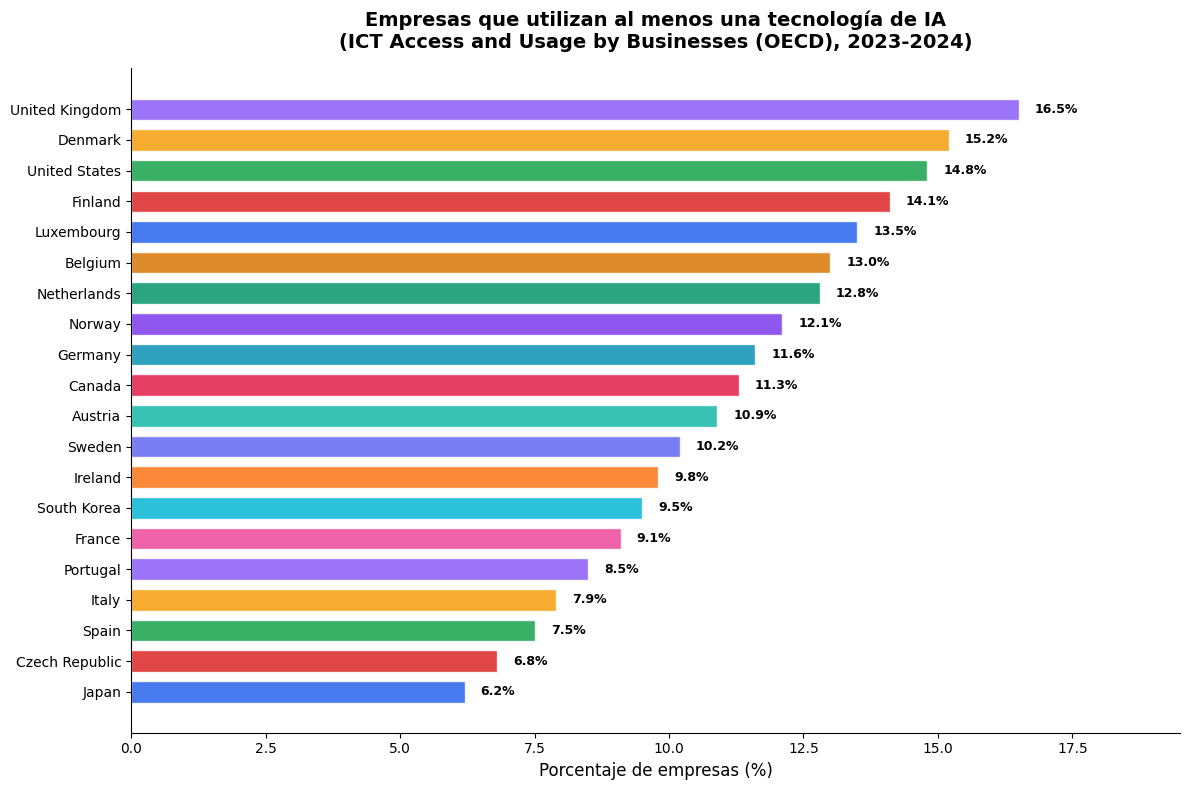

In [14]:
# Paleta de colores moderna
COLORES = [
    '#2563eb', '#dc2626', '#16a34a', '#f59e0b', '#8b5cf6',
    '#ec4899', '#06b6d4', '#f97316', '#6366f1', '#14b8a6',
    '#e11d48', '#0891b2', '#7c3aed', '#059669', '#d97706'
]

# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds1 = ocde_data['datasets']['empresas_usando_ia']
df1 = pd.DataFrame(ds1['datos'])
df1 = df1.sort_values('valor')

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(range(len(df1)), df1['valor'].values,
               color=COLORES[:len(df1)], edgecolor='white',
               height=0.7, alpha=0.85)
ax.set_yticks(range(len(df1)))
ax.set_yticklabels(df1['pais'].values, fontsize=10)
ax.set_xlabel(ds1['unidad'], fontsize=12)
ax.set_title(f"{ds1['titulo']}\n({ds1['fuente_especifica']}, {ds1['periodo']})",
             fontsize=14, fontweight='bold', pad=15)

for i, (bar, val) in enumerate(zip(bars, df1['valor'].values)):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center',
            fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, df1['valor'].max() + 3)
plt.tight_layout()
plt.show()

### 📊 Gráfico 2: Gasto en I+D como porcentaje del PIB

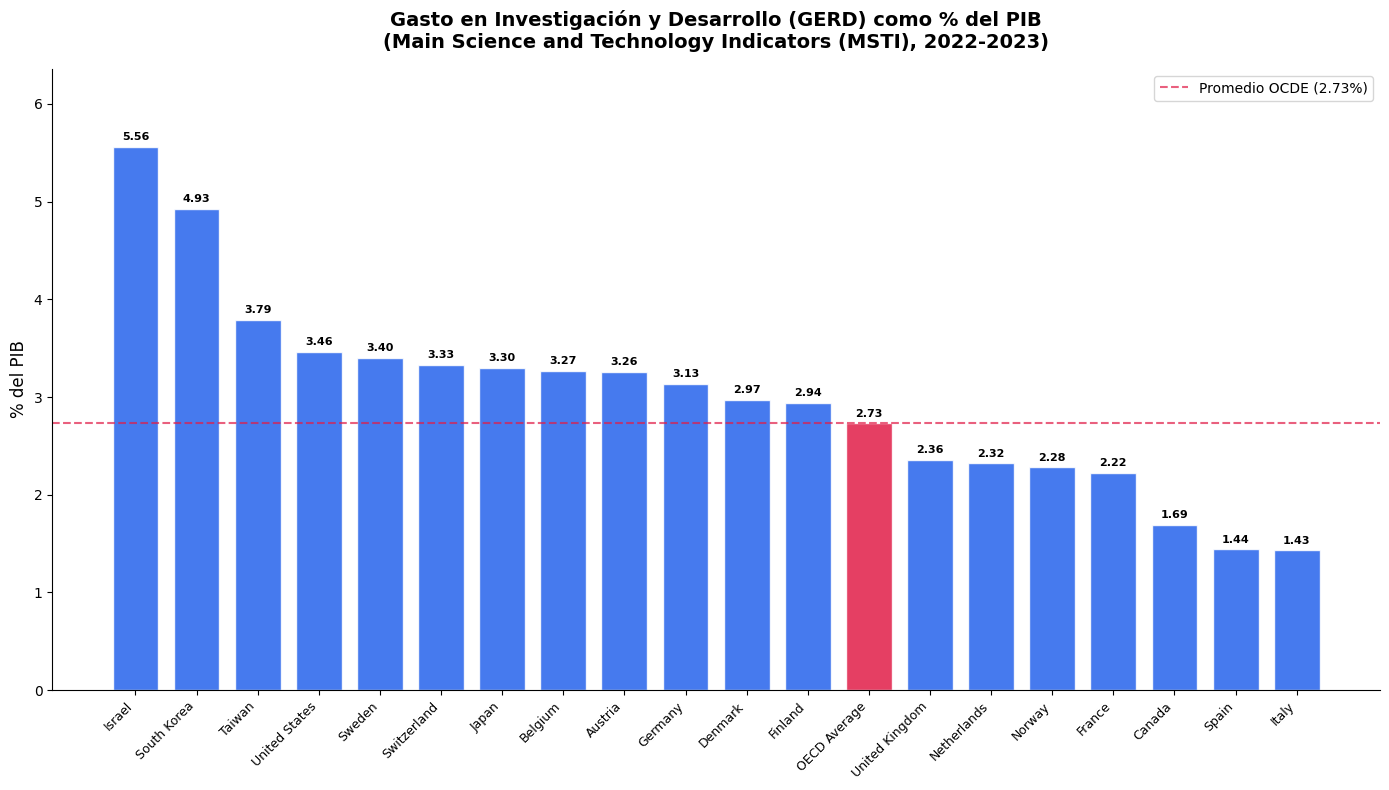

In [8]:
# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds2 = ocde_data['datasets']['gasto_id_pib']
df2 = pd.DataFrame(ds2['datos'])
df2 = df2.sort_values('valor', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# Colores: rojo para promedio OCDE, azul para el resto
colores_rd = ['#e11d48' if p == 'OECD Average' else '#2563eb'
              for p in df2['pais'].values]

bars = ax.bar(range(len(df2)), df2['valor'].values,
              color=colores_rd, edgecolor='white',
              width=0.75, alpha=0.85)
ax.set_xticks(range(len(df2)))
ax.set_xticklabels(df2['pais'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel(ds2['unidad'], fontsize=12)
ax.set_title(f"{ds2['titulo']}\n({ds2['fuente_especifica']}, {ds2['periodo']})",
             fontsize=14, fontweight='bold', pad=15)

# Línea promedio OCDE
avg = df2[df2['pais'] == 'OECD Average']['valor'].values[0]
ax.axhline(y=avg, color='#e11d48', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Promedio OCDE ({avg}%)')
ax.legend(fontsize=10, loc='upper right')

for i, val in enumerate(df2['valor'].values):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, df2['valor'].max() + 0.8)
plt.tight_layout()
plt.show()

### 📊 Gráfico 3: Publicaciones científicas sobre IA

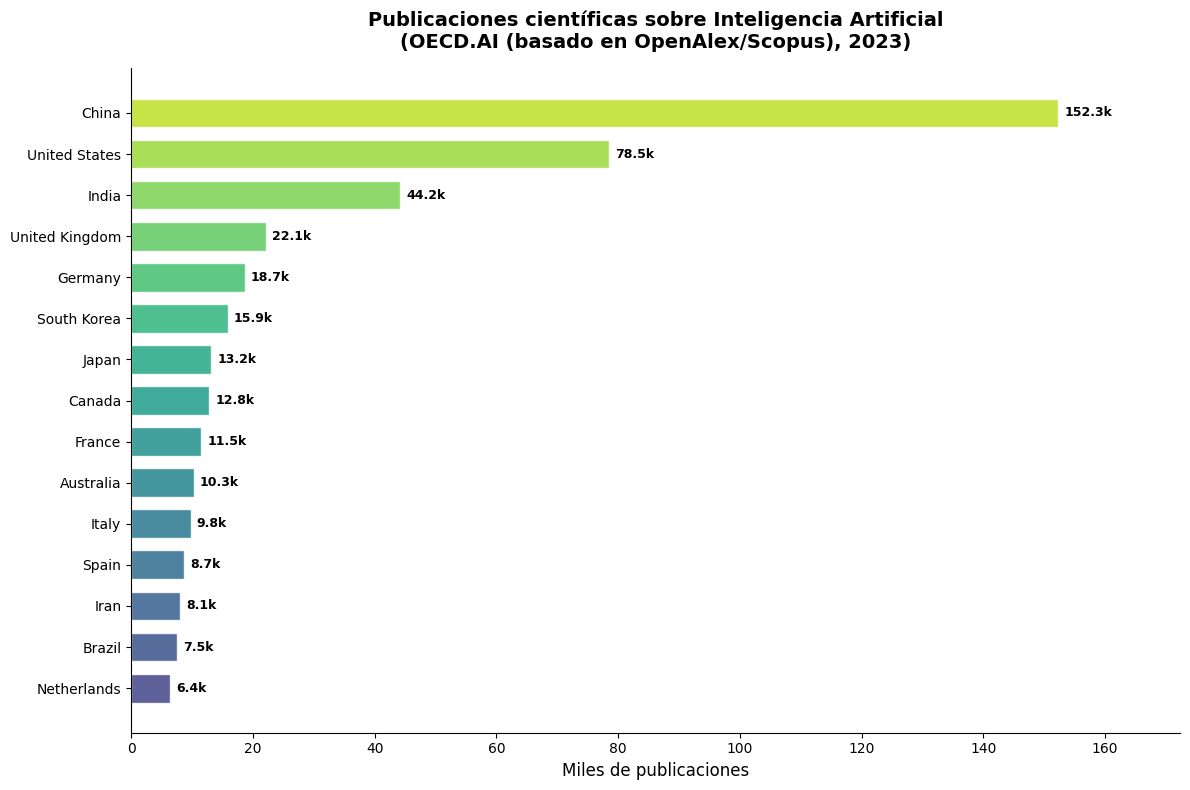

In [9]:
# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds3 = ocde_data['datasets']['publicaciones_ia']
df3 = pd.DataFrame(ds3['datos'])
df3 = df3.sort_values('valor')

fig, ax = plt.subplots(figsize=(12, 8))

gradient_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(df3)))

bars = ax.barh(range(len(df3)), df3['valor'].values,
               color=gradient_colors, edgecolor='white',
               height=0.7, alpha=0.85)
ax.set_yticks(range(len(df3)))
ax.set_yticklabels(df3['pais'].values, fontsize=10)
ax.set_xlabel(ds3['unidad'], fontsize=12)
ax.set_title(f"{ds3['titulo']}\n({ds3['fuente_especifica']}, {ds3['periodo']})",
             fontsize=14, fontweight='bold', pad=15)

for i, val in enumerate(df3['valor'].values):
    ax.text(val + 1, i, f'{val:.1f}k', va='center',
            fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, df3['valor'].max() + 20)
plt.tight_layout()
plt.show()

### 📊 Gráfico 4: Patentes de IA por país

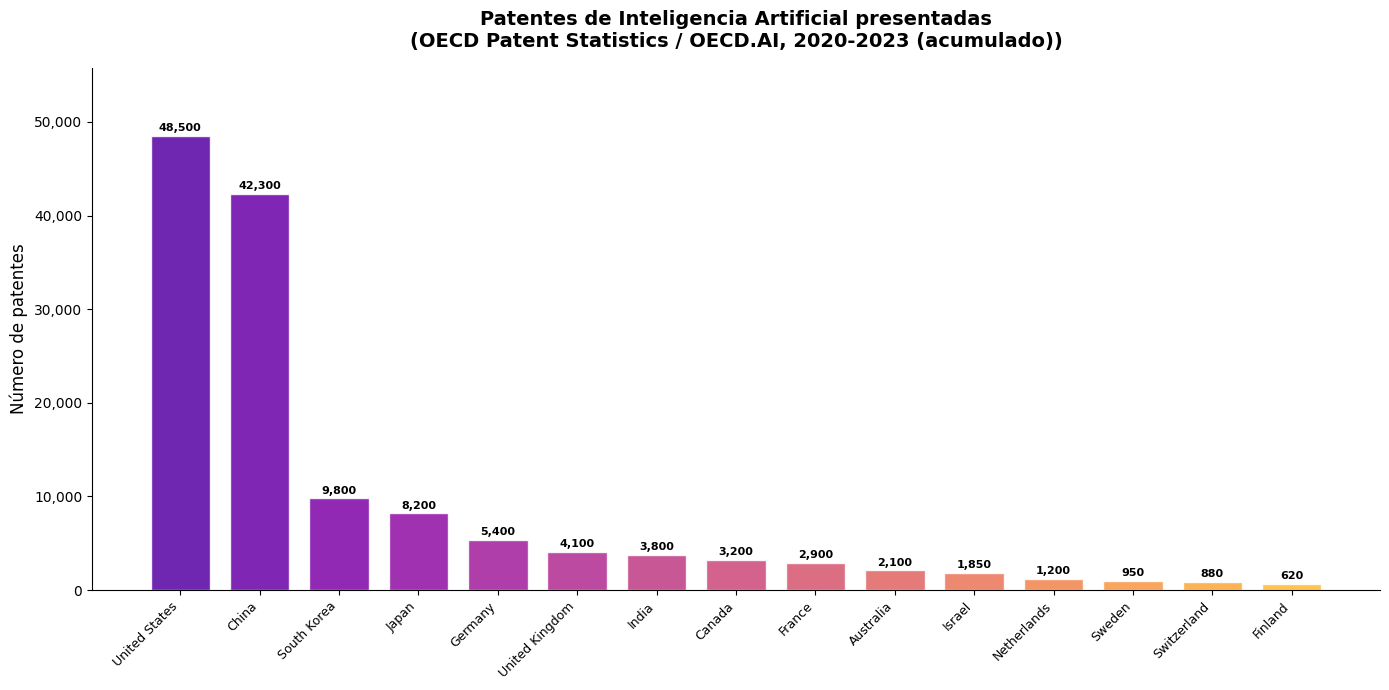

In [10]:
# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds4 = ocde_data['datasets']['patentes_ia']
df4 = pd.DataFrame(ds4['datos'])
df4 = df4.sort_values('valor', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(range(len(df4)), df4['valor'].values,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, len(df4))),
              edgecolor='white', width=0.75, alpha=0.85)
ax.set_xticks(range(len(df4)))
ax.set_xticklabels(df4['pais'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel(ds4['unidad'], fontsize=12)
ax.set_title(f"{ds4['titulo']}\n({ds4['fuente_especifica']}, {ds4['periodo']})",
             fontsize=14, fontweight='bold', pad=15)

for i, val in enumerate(df4['valor'].values):
    ax.text(i, val + 300, f'{val:,}', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, df4['valor'].max() * 1.15)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 📊 Gráfico 5: Inversión privada en IA

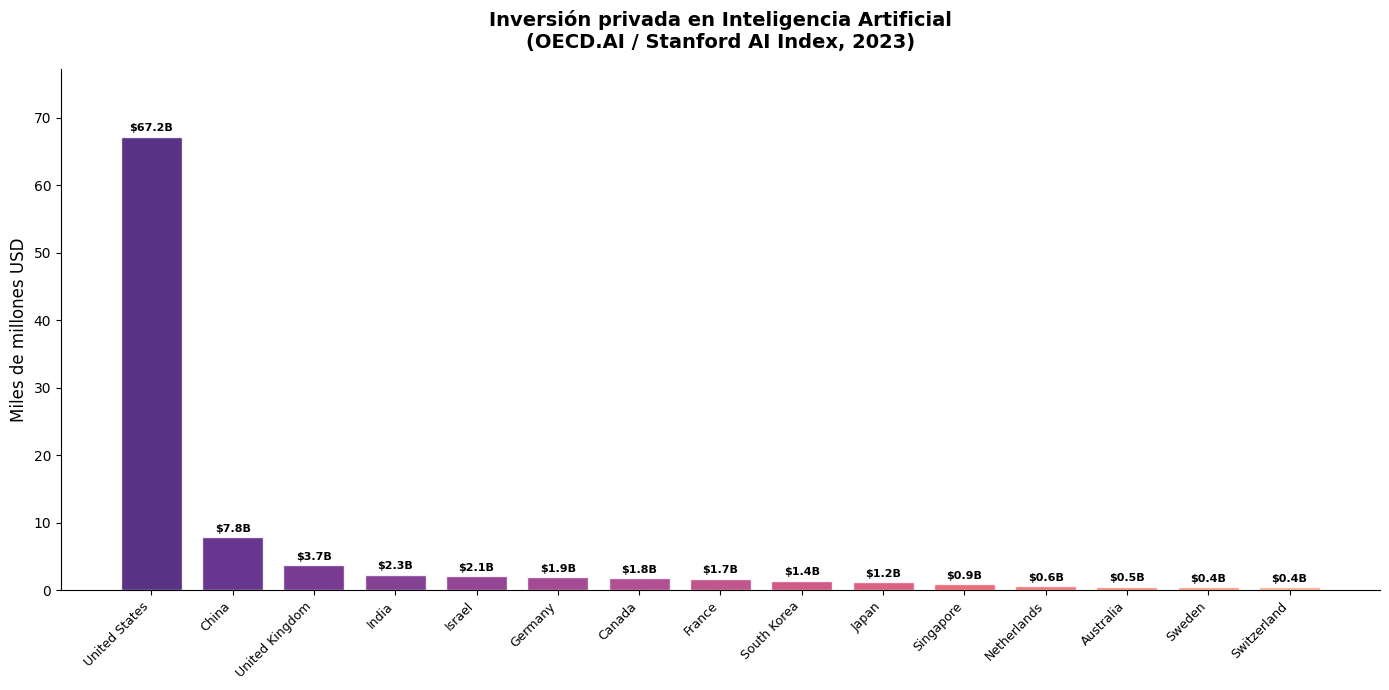

In [11]:
# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds5 = ocde_data['datasets']['inversion_privada_ia']
df5 = pd.DataFrame(ds5['datos'])
df5 = df5.sort_values('valor', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(range(len(df5)), df5['valor'].values,
              color=plt.cm.magma(np.linspace(0.2, 0.8, len(df5))),
              edgecolor='white', width=0.75, alpha=0.85)
ax.set_xticks(range(len(df5)))
ax.set_xticklabels(df5['pais'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel(ds5['unidad'], fontsize=12)
ax.set_title(f"{ds5['titulo']}\n({ds5['fuente_especifica']}, {ds5['periodo']})",
             fontsize=14, fontweight='bold', pad=15)

for i, val in enumerate(df5['valor'].values):
    ax.text(i, val + 0.5, f'${val:.1f}B', ha='center', va='bottom',
            fontsize=8, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, df5['valor'].max() * 1.15)
plt.tight_layout()
plt.show()

### 📊 Gráfico 6: Relación entre Gasto en I+D y Adopción de IA

Scatter plot que muestra la correlación entre el gasto en I+D (% del PIB) y el porcentaje de empresas que adoptan IA en cada país.

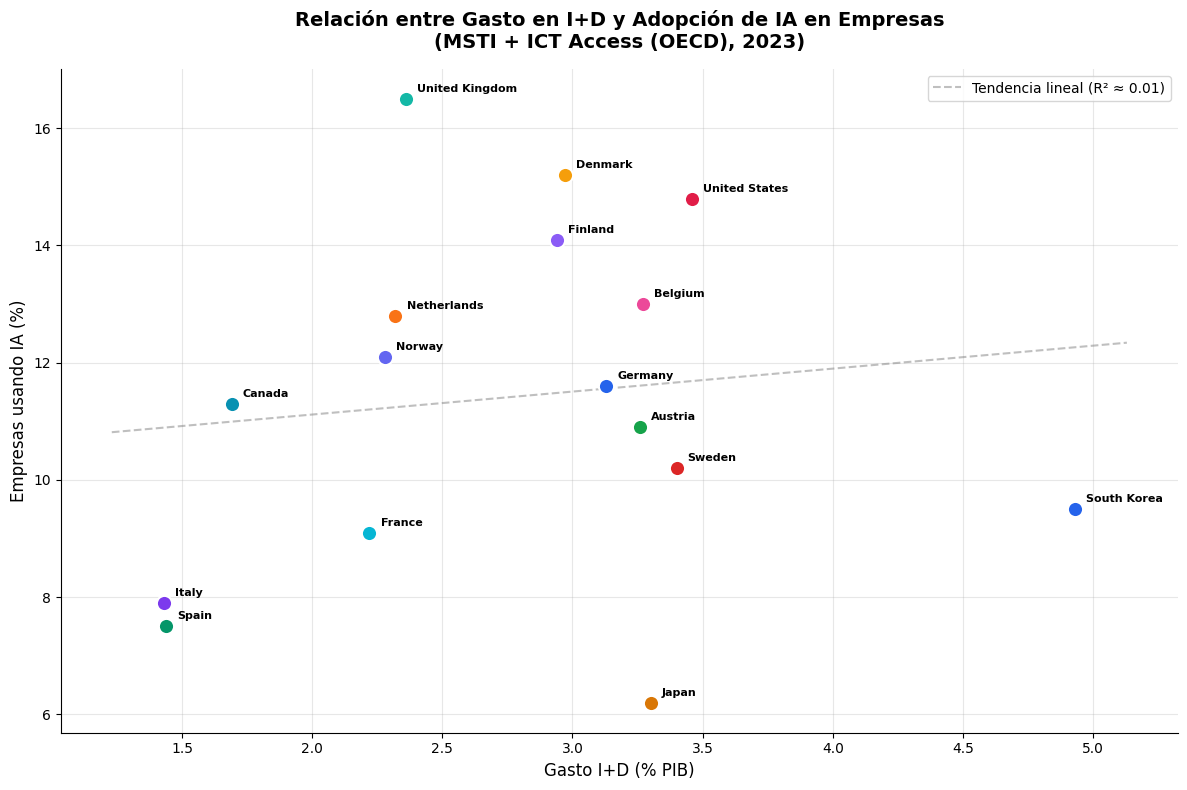

In [12]:
# ─── Leer dataset desde JSON ─────────────────────────────────────────
ds6 = ocde_data['datasets']['rd_vs_adopcion_ia']
df6 = pd.DataFrame(ds6['datos'])

fig, ax = plt.subplots(figsize=(12, 8))

for i, row in df6.iterrows():
    color = COLORES[i % len(COLORES)]
    ax.scatter(row['gasto_id'], row['adopcion_ia'], s=120,
               color=color, edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate(row['pais'], (row['gasto_id'], row['adopcion_ia']),
                textcoords='offset points', xytext=(8, 5),
                fontsize=8, fontweight='bold')

# Línea de tendencia
x_vals = df6['gasto_id'].values
y_vals = df6['adopcion_ia'].values
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
r2 = np.corrcoef(x_vals, y_vals)[0, 1] ** 2
x_line = np.linspace(x_vals.min() - 0.2, x_vals.max() + 0.2, 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.5, linewidth=1.5,
        label=f'Tendencia lineal (R² ≈ {r2:.2f})')

ax.set_xlabel(ds6['variables'][0], fontsize=12)
ax.set_ylabel(ds6['variables'][1], fontsize=12)
ax.set_title(f"{ds6['titulo']}\n({ds6['fuente_especifica']}, {ds6['periodo']})",
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()